In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

In [3]:

df = pd.read_csv("diabetic_data.csv")

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (88912, 50)
   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                6.0                      25.0                  1.0   
1                1.0                       1.0                  7.0   
2                1.0                       1.0                  7.0   
3                1.0                       1.0                  7.0   
4                1.0                       1.0                  7.0   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0               1.0  ...          No  

In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
encounter_id                    0
patient_nbr                     0
race                            0
gender                          1
age                             1
weight                          1
admission_type_id               1
discharge_disposition_id        1
admission_source_id             1
time_in_hospital                1
payer_code                      1
medical_specialty               1
num_lab_procedures              1
num_procedures                  1
num_medications                 1
number_outpatient               1
number_emergency                1
number_inpatient                1
diag_1                          1
diag_2                          1
diag_3                          1
number_diagnoses                1
max_glu_serum               83716
A1Cresult                   74164
metformin                       1
repaglinide                     1
nateglinide                     1
chlorpropamide                  1
glimepiride                     

In [5]:
df.drop(columns=["weight", "payer_code", "medical_specialty"], inplace=True)

In [6]:
print("Dataset information:")
print(df.info())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88912 entries, 0 to 88911
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   encounter_id              88912 non-null  int64  
 1   patient_nbr               88912 non-null  int64  
 2   race                      88912 non-null  object 
 3   gender                    88911 non-null  object 
 4   age                       88911 non-null  object 
 5   admission_type_id         88911 non-null  float64
 6   discharge_disposition_id  88911 non-null  float64
 7   admission_source_id       88911 non-null  float64
 8   time_in_hospital          88911 non-null  float64
 9   num_lab_procedures        88911 non-null  float64
 10  num_procedures            88911 non-null  float64
 11  num_medications           88911 non-null  float64
 12  number_outpatient         88911 non-null  float64
 13  number_emergency          88911 non-null

In [7]:
df["target"] = (df["readmitted"] == "<30").astype(int)

print("Target distribution:")
print(df["target"].value_counts())

Target distribution:
target
0    78903
1    10009
Name: count, dtype: int64


In [8]:
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

X = df[features]
y = df["target"]

print("Selected features:")
print(X.head())

Selected features:
   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0               1.0                41.0             0.0              1.0   
1               3.0                59.0             0.0             18.0   
2               2.0                11.0             5.0             13.0   
3               2.0                44.0             1.0             16.0   
4               1.0                51.0             0.0              8.0   

   number_outpatient  number_emergency  number_inpatient  number_diagnoses  
0                0.0               0.0               0.0               1.0  
1                0.0               0.0               0.0               9.0  
2                2.0               0.0               1.0               6.0  
3                0.0               0.0               0.0               7.0  
4                0.0               0.0               0.0               5.0  


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (71129, 8)
Testing data shape: (17783, 8)


In [12]:
model = LogisticRegression(
    penalty="l2",
    class_weight="balanced",
    max_iter=1000
)

# Create a mask for rows with NaN values in X_train
nan_mask_train = X_train.isnull().any(axis=1)

# Drop rows with NaN values from X_train and y_train
X_train_cleaned = X_train[~nan_mask_train]
y_train_cleaned = y_train[~nan_mask_train]

model.fit(X_train_cleaned, y_train_cleaned)

print("Model trained successfully!")

Model trained successfully!


In [13]:
print("Intercept:")
print(model.intercept_)

print("\nCoefficients:")

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients)

Intercept:
[-0.86782721]

Coefficients:
              Feature  Coefficient
0    time_in_hospital     0.031530
1  num_lab_procedures    -0.000448
2      num_procedures    -0.034265
3     num_medications     0.007250
4   number_outpatient    -0.013315
5    number_emergency     0.080699
6    number_inpatient     0.285659
7    number_diagnoses     0.056532


In [14]:
y_probability = model.predict_proba(X_test)[:, 1]

print("First 10 predicted probabilities:")
print(y_probability[:10])

First 10 predicted probabilities:
[0.36547736 0.50477278 0.46951704 0.47468746 0.39023774 0.47062626
 0.46962688 0.47868331 0.52862629 0.47179572]


In [15]:
print("Minimum probability:", y_probability.min())
print("Maximum probability:", y_probability.max())
print("Mean probability:", y_probability.mean())
print("Predicted 1s:", (y_probability >= 0.5).sum())

Minimum probability: 0.2944238995286808
Maximum probability: 0.9981669982117098
Mean probability: 0.47894421805426773
Predicted 1s: 5525


In [16]:
auc = roc_auc_score(y_test, y_probability)

print("ROC-AUC Score:")
print(auc)

ROC-AUC Score:
0.6304998625985888


In [17]:
threshold = 0.5

y_pred = (y_probability >= threshold).astype(int)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[0 1 0 0 0 0 0 0 1 0]


In [18]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[11203  4578]
 [ 1055   947]]


In [19]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 11203
False Positives: 4578
False Negatives: 1055
True Positives : 947


In [20]:
FN_COST = 5
FP_COST = 1

false_negative_cost = fn * FN_COST
false_positive_cost = fp * FP_COST

total_cost = false_negative_cost + false_positive_cost

print("Clinical Cost Analysis")
print("----------------------")
print("False Negative Cost:", false_negative_cost)
print("False Positive Cost:", false_positive_cost)
print("Total Clinical Cost:", total_cost)

Clinical Cost Analysis
----------------------
False Negative Cost: 5275
False Positive Cost: 4578
Total Clinical Cost: 9853


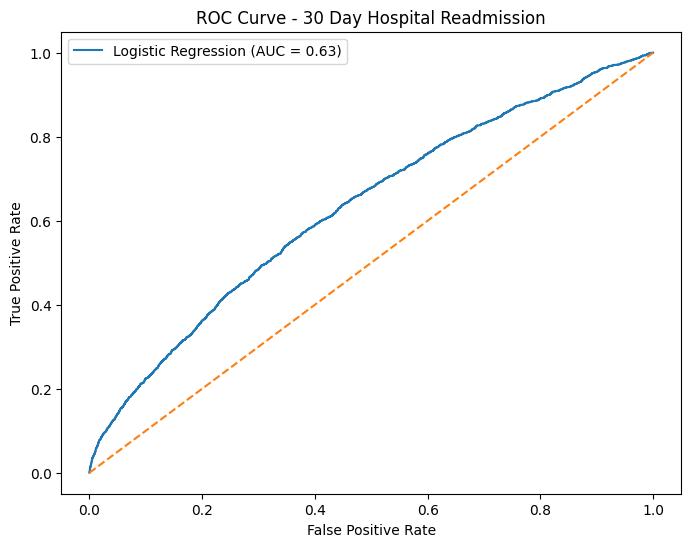

In [21]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30 Day Hospital Readmission")

plt.legend()

plt.show()